In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
from matplotlib import pyplot as plt

import datasets_util
import vis_util
import lpca
from lego import lego, util

VIS = vis_util.Visualize('figures/wave_on_circle/')

matplotlib.get_backend() =  inline


In [3]:
np.random.seed(42)
radius = 1.0  # Base radius of the circle
wave_amplitude = 0.2  # Amplitude of the wave
wave_frequency = 10  # Number of oscillations around the circle

n = 5000
theta = np.mod(0.5*np.pi*np.random.normal(0, 1, n), 2*np.pi)
r = radius + wave_amplitude * np.sin(wave_frequency * theta)
X0 = np.zeros((n,2))
X0[:,0] = r * np.cos(theta)
X0[:,1] = r * np.sin(theta)

In [4]:
normal_dir = np.zeros((n,2))
r_prime = wave_amplitude * wave_frequency * np.cos(wave_frequency * theta)
normal_dir[:,0] = -(r_prime * np.sin(theta) + r * np.cos(theta))
normal_dir[:,1] = r_prime * np.cos(theta) - r * np.sin(theta)
normal_dir = normal_dir/np.linalg.norm(normal_dir, axis=1)[:,None]

In [5]:
np.random.seed(42)
noise_sigma = 0.08*(np.cos(3*theta)**2)
noise = np.random.uniform(-noise_sigma, noise_sigma)
X = X0 + noise[:,None]*normal_dir

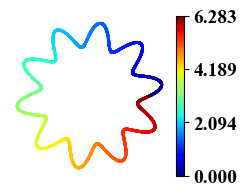

In [6]:
VIS.data(X0, theta, elev=26, azim=-42, cmap='jet', colorbar=True, title='', save_fn='clean_data', figsize=(3,3), show_axis=False)

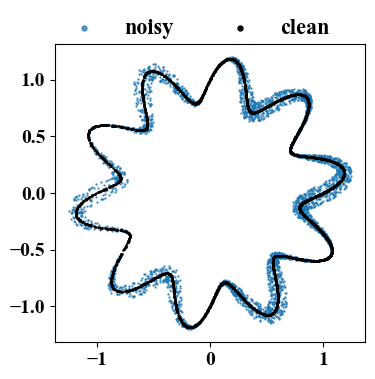

In [7]:
plt.figure(figsize=(4,4))
plt.scatter(*X.T, alpha=0.75, s=2, label='noisy')
plt.scatter(*X0.T, color='k', alpha=1, s=2, label='clean')
plt.legend(loc='upper right', markerscale=5, bbox_to_anchor=(0.95, 1.15), frameon=False, ncol=2)
plt.axis('image')
plt.savefig(VIS.save_dir + '/noisy_data.png', dpi=600)
plt.show()

In [8]:
# to plot tangent vectors at
n_subsample = 100
thetas_to_eval_at = np.linspace(0, 2*np.pi, n_subsample)
subsample_inds = np.argmin(np.abs(thetas_to_eval_at[None,:]-theta[:,None]), axis=0)

In [9]:
emb_dim = 1
k_nn = 14

# LPCA on noiseless data

In [10]:
gt_estimate = lpca.lpca(X0, opts = {'emb_dim': emb_dim, 'k_nn': k_nn})

In [11]:
gt_estimate['tang_basis'].shape

(5000, 1, 2)

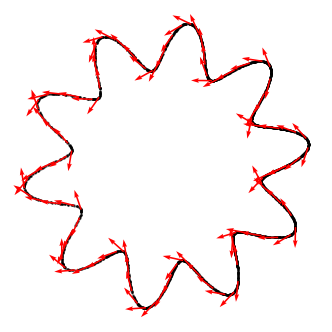

In [12]:
VIS.plot_tangent_vectors_1d_in_2d(
    gt_estimate['tang_basis'],
    None, X0, subsample_inds,
    title='', save_fn='gt_tang_basis'
)

# LPCA on noisy data

In [13]:
lpca_estimate = lpca.lpca(X, opts = {'emb_dim': emb_dim, 'k_nn': k_nn})

/home/dk5661/codebase/LEGO/examples/vis_util.py:366: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(*X.T, c=c, cmap='jet', s=s, alpha=alpha)


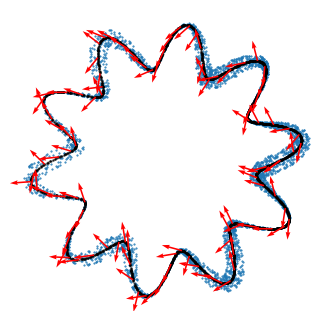

In [14]:
VIS.plot_tangent_vectors_1d_in_2d(
    lpca_estimate['tang_basis'],
    X, X0, subsample_inds,
    title='', save_fn='lpca_tang_basis'
)

# LEGO on noisy data

In [15]:
n_eig_for_grad = 20
n_eig = 100
lego_estimate = lego.lego(
    X,
    opts={'emb_dim': emb_dim, 'k_nn': k_nn, 'n_eig_for_grad': n_eig_for_grad}, 
    gl_opts={'n_eig': n_eig}
)

/home/dk5661/codebase/LEGO/examples/vis_util.py:366: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(*X.T, c=c, cmap='jet', s=s, alpha=alpha)


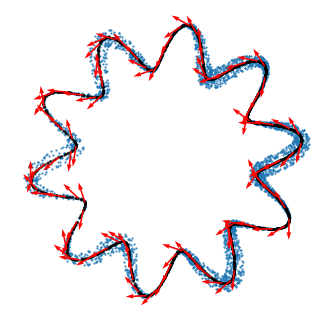

In [16]:
VIS.plot_tangent_vectors_1d_in_2d(
    lego_estimate['tang_basis'],
    X, X0, subsample_inds,
    title='', save_fn='lego_tang_basis'
)

# Error of LPCA and LEGO estimates

In [17]:
color = {'lpca': 'red', 'lego': 'green'}
error = {
    'lpca': {'lpca': util.tang_basis_estimate_error(lpca_estimate['tang_basis'], gt_estimate['tang_basis'])},
    'lego': {'lego': util.tang_basis_estimate_error(lego_estimate['tang_basis'], gt_estimate['tang_basis'])},
}

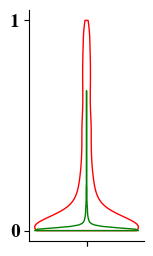

In [18]:
_ = VIS.global_distortion_viloinplot_overlay(
    error, log_scale=False, legend=False, filled=False,
    color = color, remove_annotation=True, offset2=0, offset1=0,
    title='', label='', figsize=(2,3), save_fn='error_violins'
)

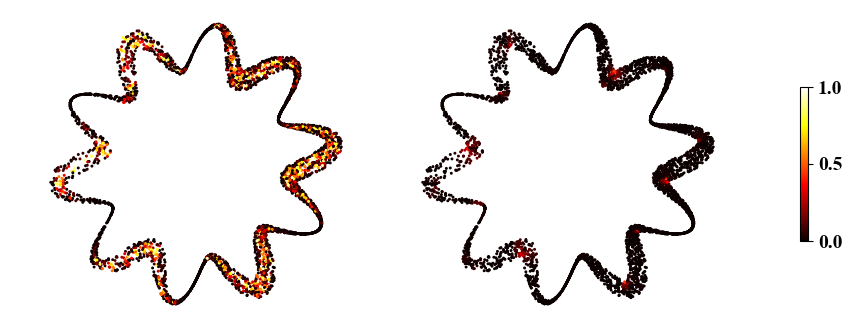

In [19]:
VIS.compare_principal_angle_discrep(
    X, [error['lpca']['lpca'], error['lego']['lego']],
    vmin=0, vmax=1, cmap='hot', save_fn='lpca_vs_lego_tang_estimate_errors'
)

# Local intrinsic dimension estimation

We simply change the embedding dimension to be equal to the ambient dimension plot the variance explained in each dimension

In [20]:
ambient_dim = X.shape[1]

In [21]:
lpca_estimate_for_lid = lpca.lpca(X, opts = {'emb_dim': ambient_dim, 'k_nn': k_nn})

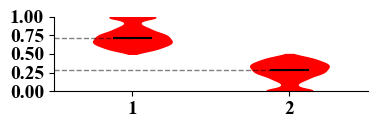

In [22]:
VIS.plot_var_exp_violin_plot(
    lpca_estimate_for_lid['var_explained'], color='r', save_fn='lpca_lid_estimate'
)

In [23]:
lego_estimate_for_lid = lego.lego(
    X,
    opts={'emb_dim': ambient_dim, 'k_nn': k_nn, 'n_eig_for_grad': n_eig_for_grad}, 
    gl_opts={'n_eig': n_eig}
)

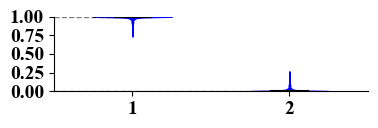

In [24]:
VIS.plot_var_exp_violin_plot(
    lego_estimate_for_lid['var_explained'], color='b', save_fn='lego_lid_estimate'
)

# Plot eigenvectors

In [25]:
output = lego.lego(
    X,
    opts={'emb_dim': emb_dim, 'k_nn': k_nn, 'n_eig_for_grad': n_eig_for_grad}, 
    gl_opts={'n_eig': n_eig},
    return_aux_info=True
)

In [27]:
import os
if not os.path.exists(VIS.save_dir + '/eigs/'):
    os.makedirs(VIS.save_dir + '/eigs/')

/tmp/ipykernel_795633/4060242287.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(3,3))


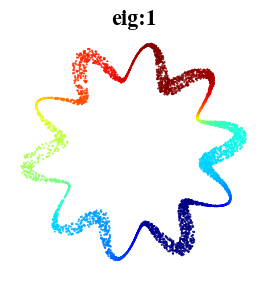

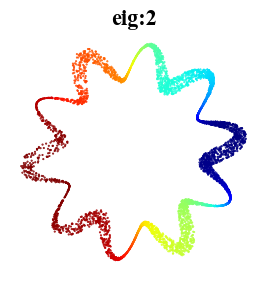

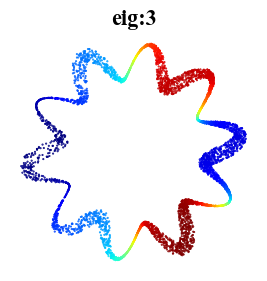

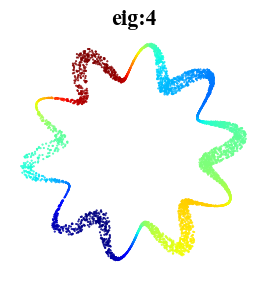

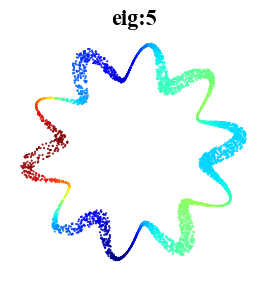

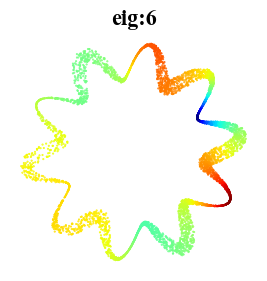

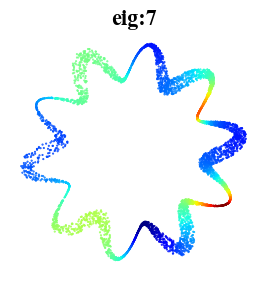

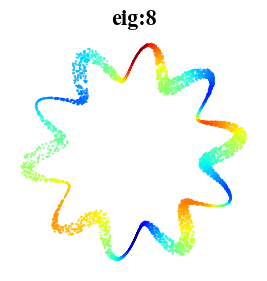

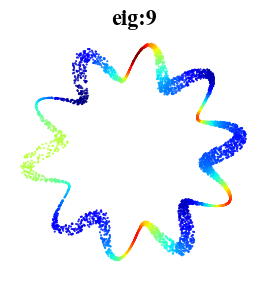

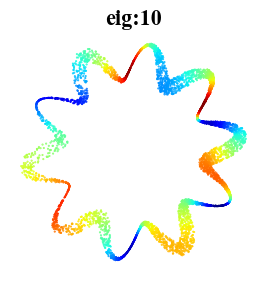

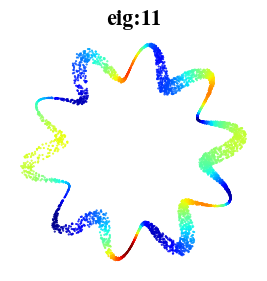

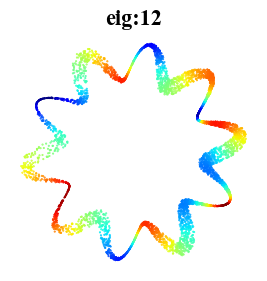

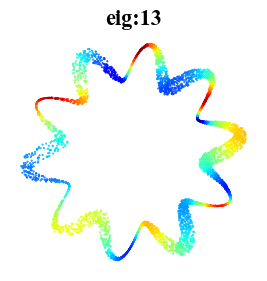

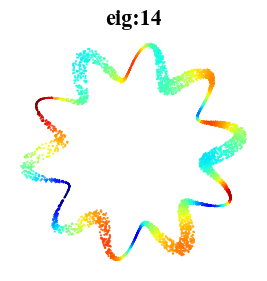

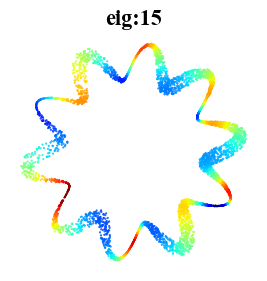

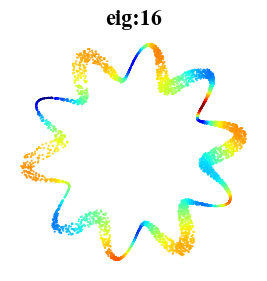

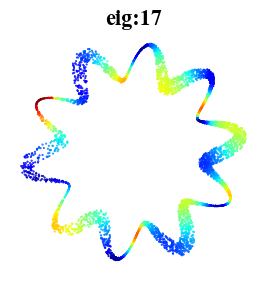

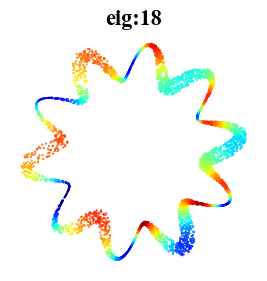

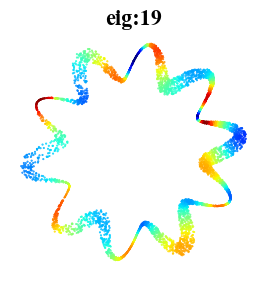

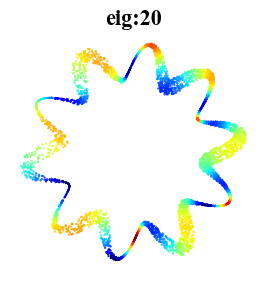

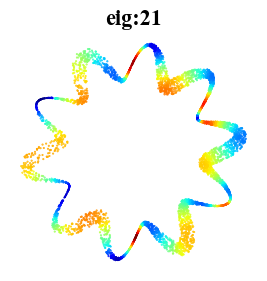

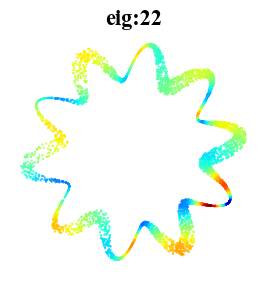

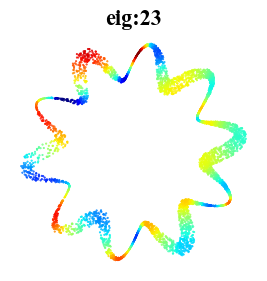

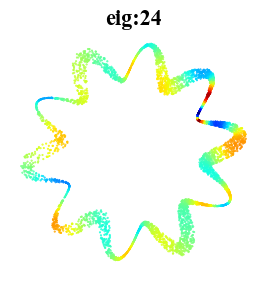

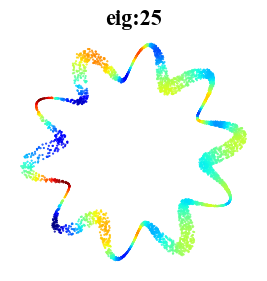

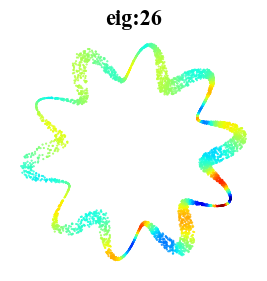

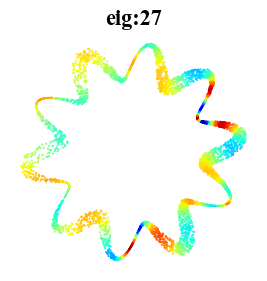

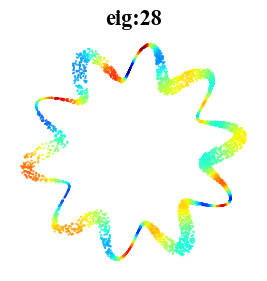

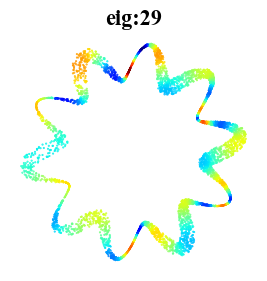

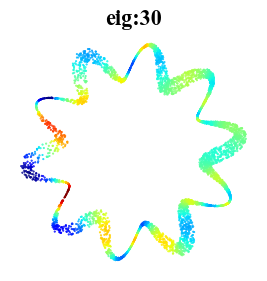

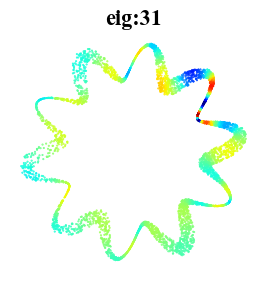

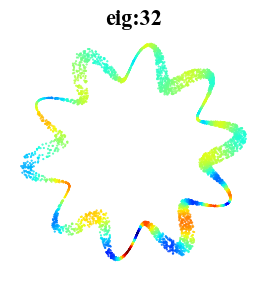

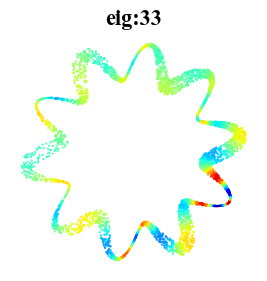

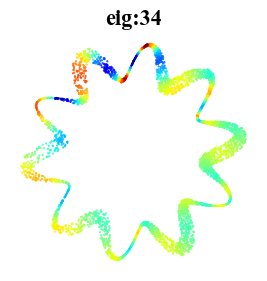

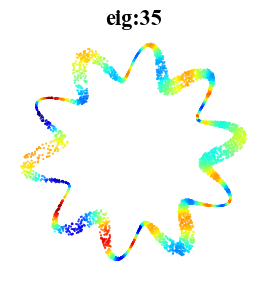

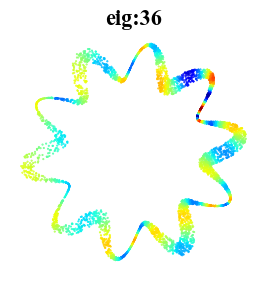

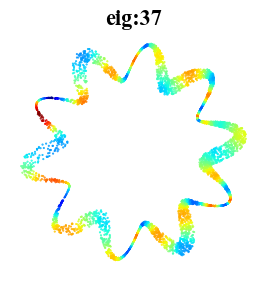

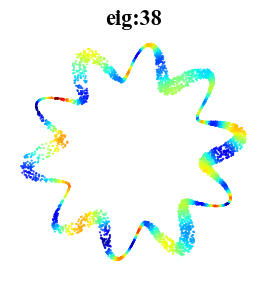

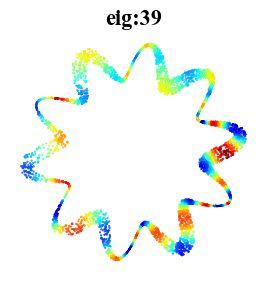

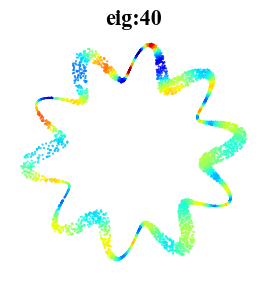

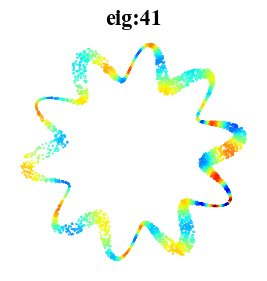

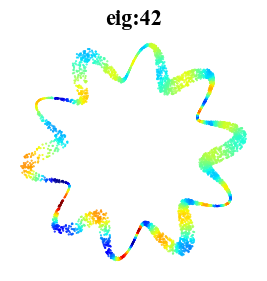

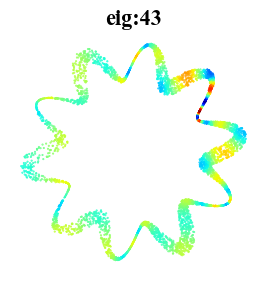

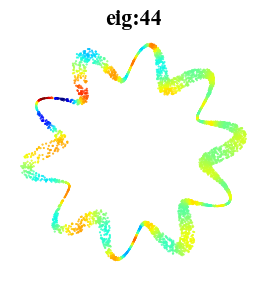

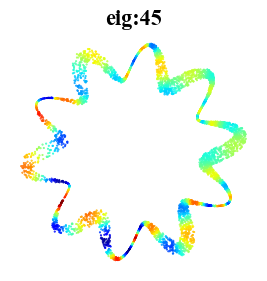

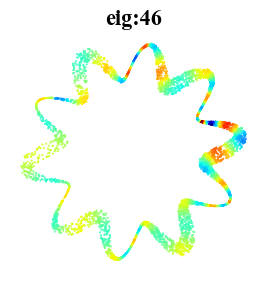

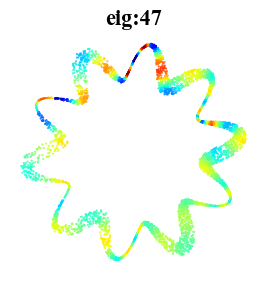

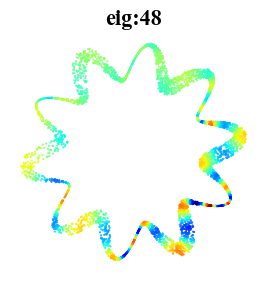

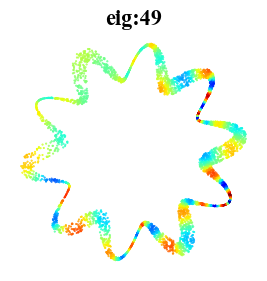

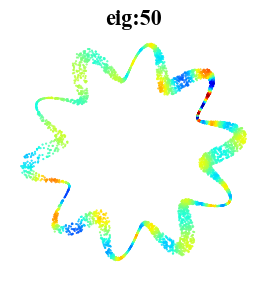

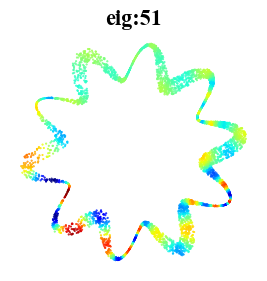

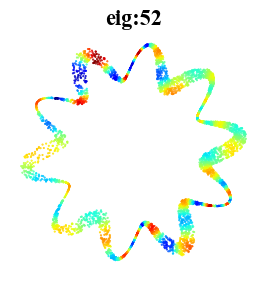

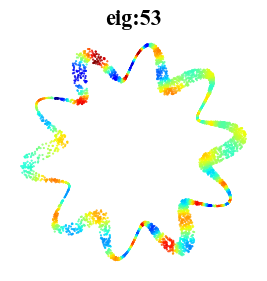

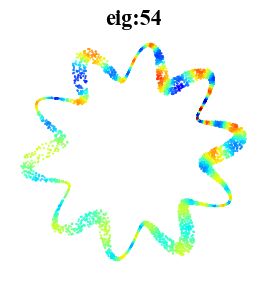

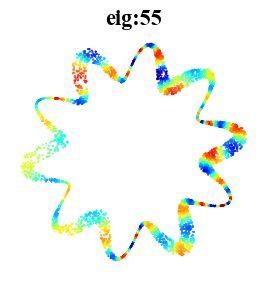

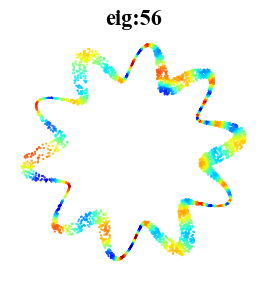

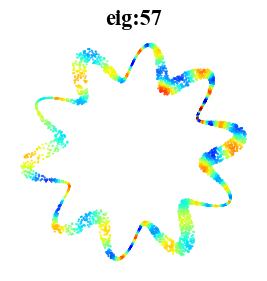

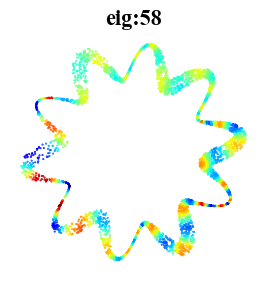

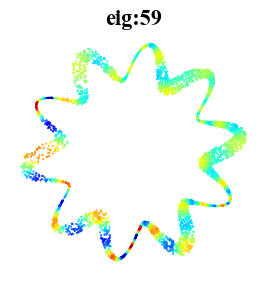

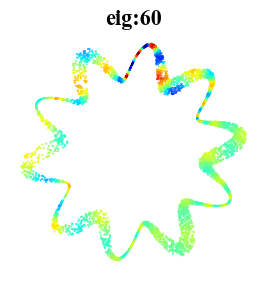

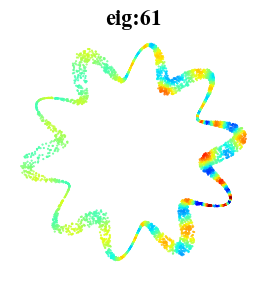

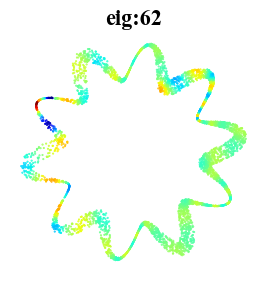

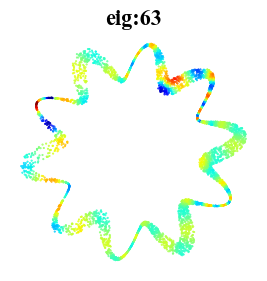

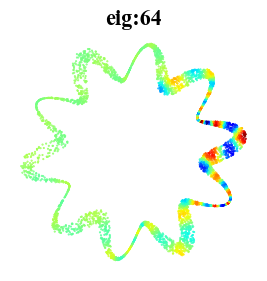

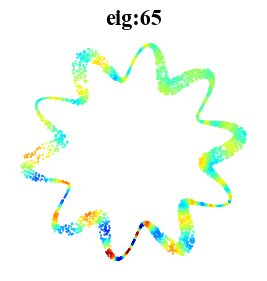

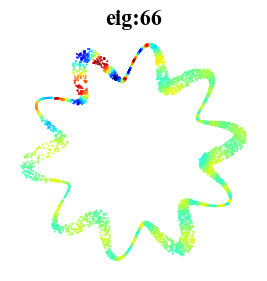

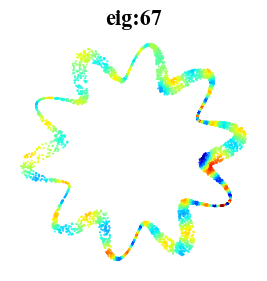

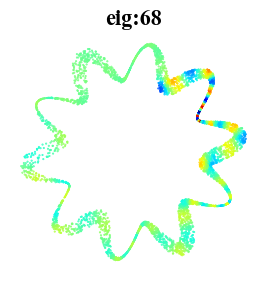

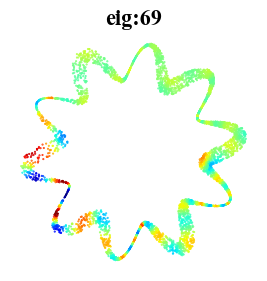

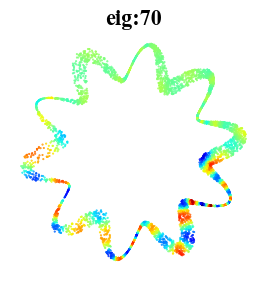

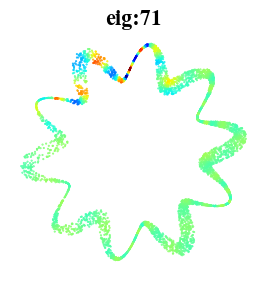

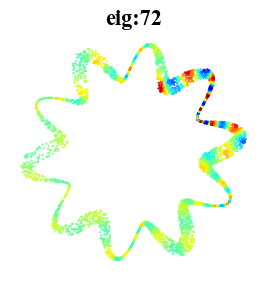

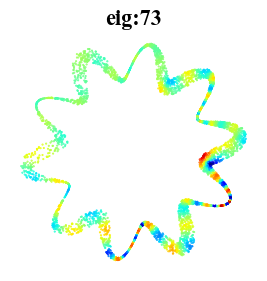

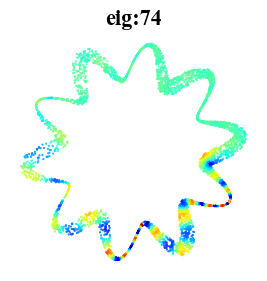

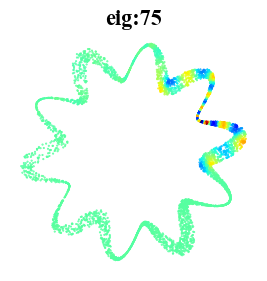

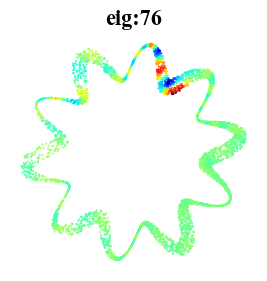

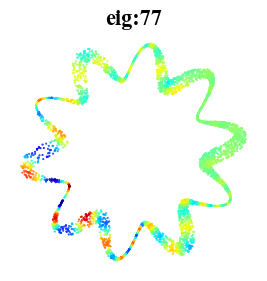

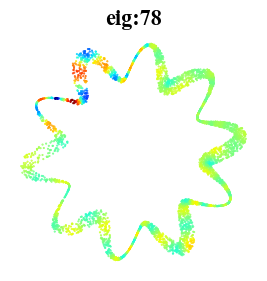

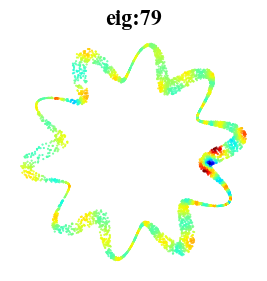

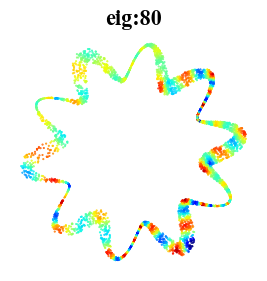

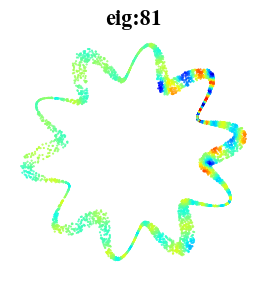

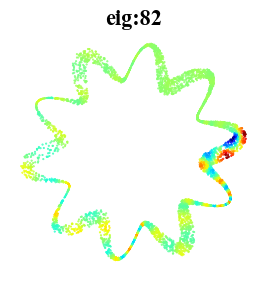

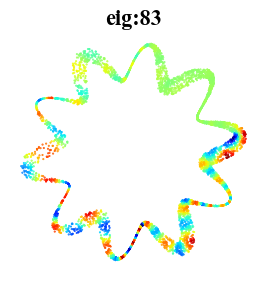

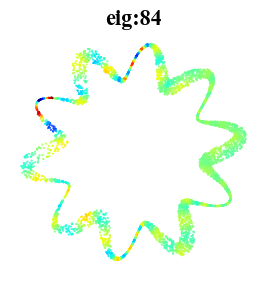

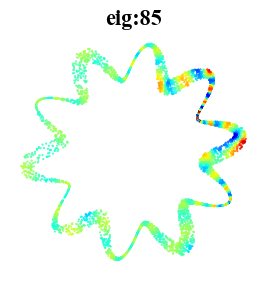

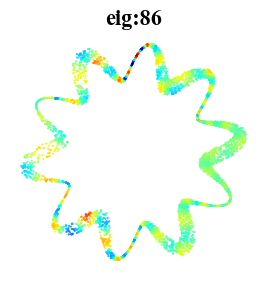

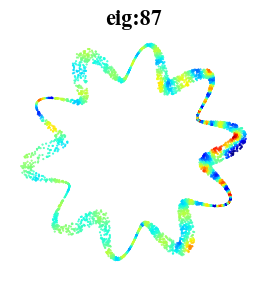

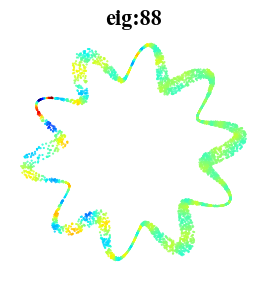

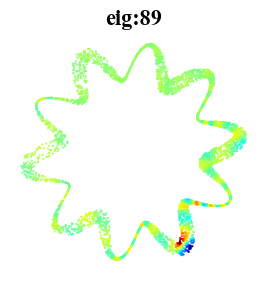

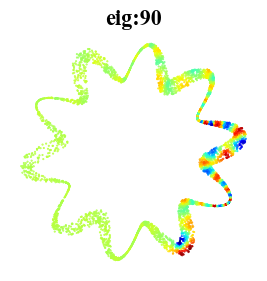

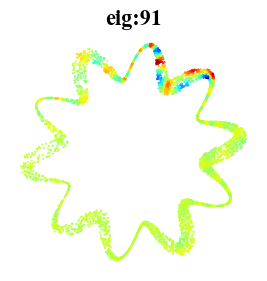

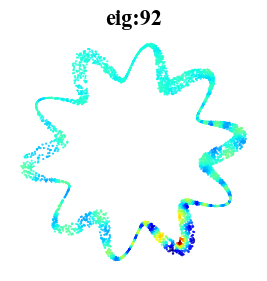

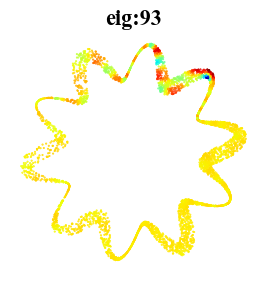

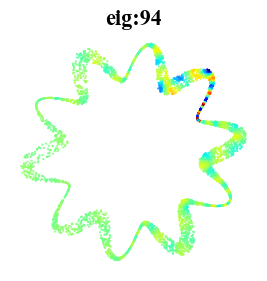

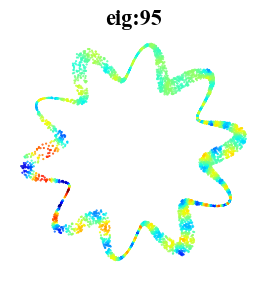

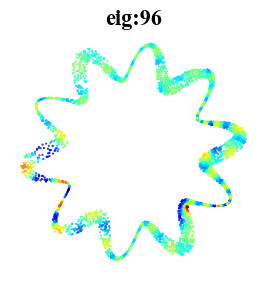

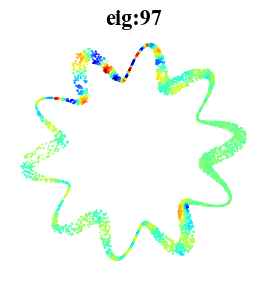

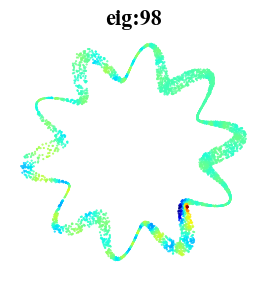

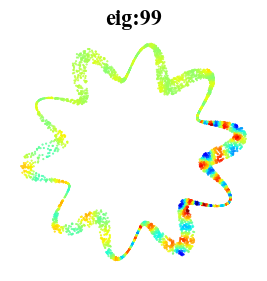

In [28]:
phi = output['phi']
for i in range(1, phi.shape[1]):
    title = 'eig:'+str(i)
    plt.figure(figsize=(3,3))
    plt.scatter(*X.T, c=phi[:,i], cmap='jet', s=1)
    plt.axis('off')
    plt.axis('image')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(VIS.save_dir + '/eigs/' + title + '.png', dpi=600)